# Lab 2.07 - Univariate Analysis

## Exercise 7 - Australian Athletes (ais)

Import all necessary Python libraries and load the AIS dataset from lab exercise 1.01. Also include the code for setting the index and conversion to categorical variables!

In [1]:
# Importing the necessary packages
import numpy as np                                  # Scientific computing
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation

ais = pd.read_csv("https://raw.githubusercontent.com/HoGentTIN/dsai-labs/refs/heads/main/data/ais.csv")
ais.set_index(["id"])
ais['sex'] = ais['sex'].astype("category")
ais['sport'] = ais['sport'].astype("category")

<class 'pandas.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   id      202 non-null    int64   
 1   rcc     202 non-null    float64 
 2   wcc     202 non-null    float64 
 3   hc      202 non-null    float64 
 4   hg      202 non-null    float64 
 5   ferr    202 non-null    int64   
 6   bmi     202 non-null    float64 
 7   ssf     202 non-null    float64 
 8   pcBfat  202 non-null    float64 
 9   lbm     202 non-null    float64 
 10  ht      202 non-null    float64 
 11  wt      202 non-null    float64 
 12  sex     202 non-null    category
 13  sport   202 non-null    category
dtypes: category(2), float64(10), int64(2)
memory usage: 19.6 KB


Use an appropriate chart type to visualise the following variables. Are several chart types suitable? Make one of each! Note how some graphs nevertheless give a better insight into the data than other types of graphs.

- `sex`
- `sport`
- `ht` (show this also divided by `sex` and by `sport`.)

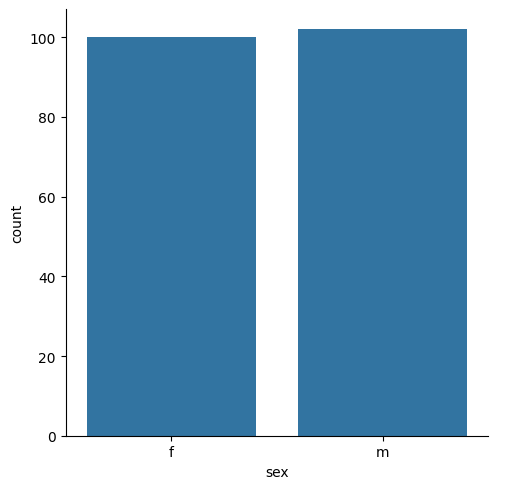

In [6]:
# sex
sns.catplot(data=ais, kind='count', x='sex')

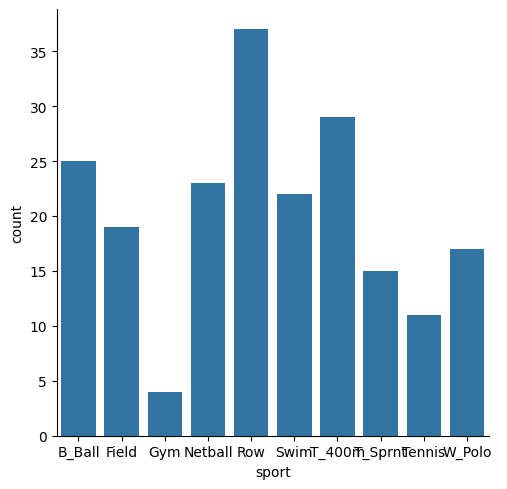

In [7]:
# sport
sns.catplot(data=ais, kind='count', x='sport')

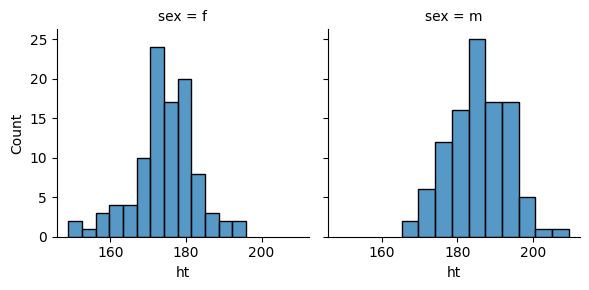

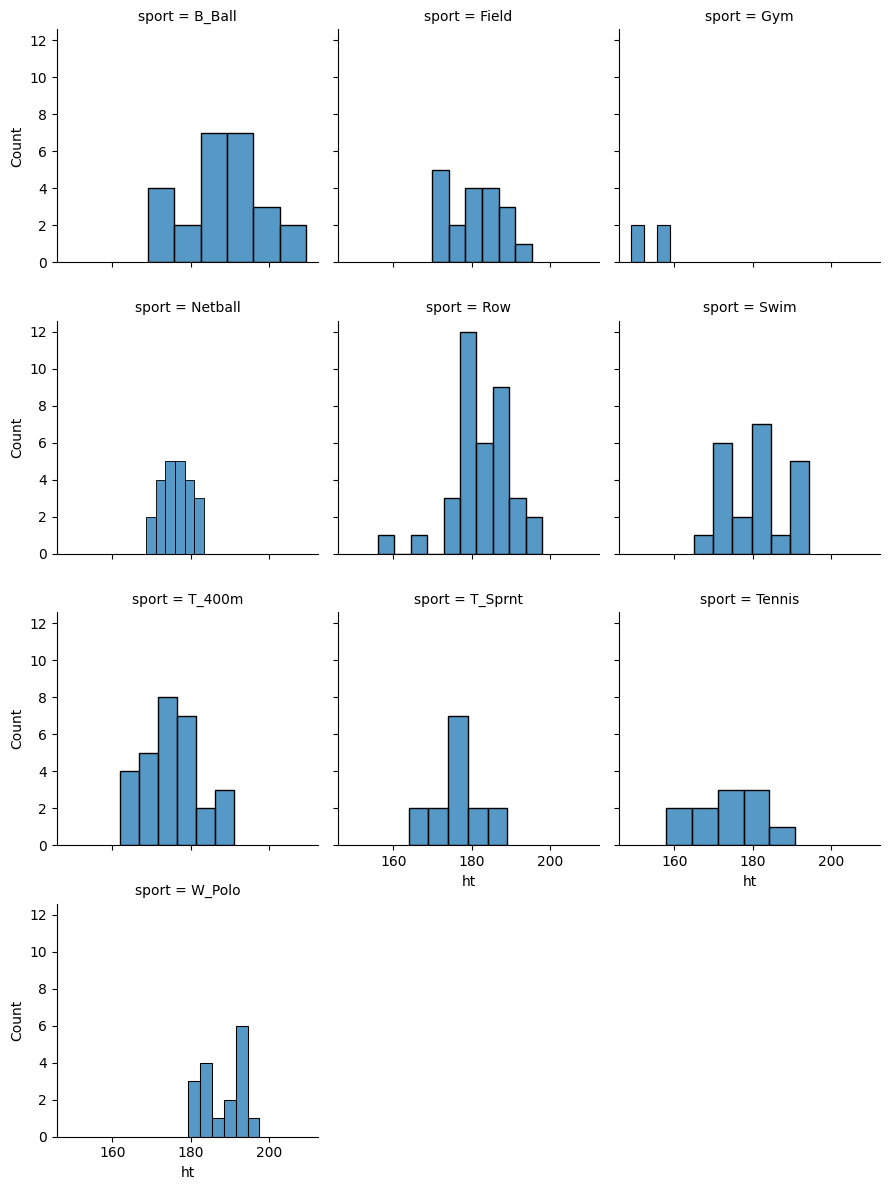

In [14]:

# height
facet_sex = sns.FacetGrid(data=ais, col='sex')
facet_sex.map(sns.histplot, 'ht')

facet_sport = sns.FacetGrid(data=ais, col='sport', col_wrap=3)
facet_sport.map(sns.histplot, 'ht')

Select the following subsets from the dataset and calculate for each the appropriate measures of central tendency (and, when possible, dispersion) of the variables `ht` and `sex`:

1. the rowers
2. the rowers, netball and tennis players together
3. the female basketball players and rowers together

In [57]:
rowers = ais.query('(sport == "Row")')
rownetten = ais.query('(sport in ["Row", "Netball", "Tennis"])')
baskrow = ais.query('(sport in ["B_Ball", "Row"]) and (sex == "f")')

counter = 1
for selection in [rowers, rownetten, baskrow]:
    print(f'Selection {counter}\nFrequencies for variable {selection["sex"].value_counts()}\nMode = {selection.sex.mode()}\n')
    mean = selection.ht.mean()
    stdev = selection.ht.std()
    min, lower_q, median, higher_q, maximum = selection.ht.quantile([0,0.25,0.5,0.75,1])
    iqr = higher_q - lower_q
    print(f'Measures of central tendency for ht:\nMean = {mean}\nStandard deviation = {stdev}\nMinimum = {min}\nQ1 = {lower_q}\nMedian = {median}\nQ3 = {higher_q}\nMaximum = {maximum}\nInterquartile range = {iqr}\n\n')
    counter += 1



Selection 1
Frequencies for variable sex
f    22
m    15
Name: count, dtype: int64
Mode = 0    f
Name: sex, dtype: category
Categories (2, str): ['f', 'm']

Measures of central tendency for ht:
Mean = 182.3756756756757
Standard deviation = 7.798376091832815
Minimum = 156.0
Q1 = 179.3
Median = 181.8
Q3 = 186.3
Maximum = 198.0
Interquartile range = 7.0


Selection 2
Frequencies for variable sex
f    52
m    19
Name: count, dtype: int64
Mode = 0    f
Name: sex, dtype: category
Categories (2, str): ['f', 'm']

Measures of central tendency for ht:
Mean = 179.0661971830986
Standard deviation = 7.936370952987299
Minimum = 156.0
Q1 = 174.25
Median = 179.5
Q3 = 183.4
Maximum = 198.0
Interquartile range = 9.150000000000006


Selection 3
Frequencies for variable sex
f    35
m     0
Name: count, dtype: int64
Mode = 0    f
Name: sex, dtype: category
Categories (2, str): ['f', 'm']

Measures of central tendency for ht:
Mean = 180.1257142857143
Standard deviation = 7.144077878879525
Minimum = 156.0
Q

## Check your answers

As a check, here are the results of the last question. First the frequencies and mode of the variable `sex`:

|           | Selection 1 | Selection 2 | Selection 3 |
| :-------- | :---------- | :---------- | :---------- |
| **f**     | 22          | 52          | 35          |
| **m**     | 15          | 19          | 0           |
| **mode**  | f           | f           | f           |

Then the relevant measures for central tendency and dispersion for `ht` (max. 3 decimal places):

| Statistic  | Selection 1 | Selection 2 | Selection 3 |
| :--------- | :---------- | :---------- | :---------- |
| mean       | 182.376     | 179.066     | 180.126     |
| stdev      | 7.798       | 7.936       | 7.144       |
| min        | 156         | 156         | 156         |
| Q1         | 179.3       | 174.25      | 177.4       |
| median     | 181.8       | 179.5       | 179.7       |
| Q3         | 186.3       | 183.4       | 184.65      |
| max        | 198         | 198         | 195.9       |
| IQR        | 7           | 9.15        | 7.250       |